In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import pandas as pd

In [2]:
root_dir = Path(r"Z:\Bel\Farid\Old_Experiment_Outputs")
# Find all CSV files recursively
csv_files = list(root_dir.rglob("*.csv"))

if not csv_files:
    print("No CSV files found.")
else:
    dfs = []
    
    for f in csv_files:
        if "analysis" in str(f):
            try:
                df = pd.read_csv(f)
                df["source_file"] = str(f)          # optional: keep track of original file
                df["source_folder"] = str(f.parent) # optional
                dfs.append(df)
                print(f"Loaded: {f}")
            except Exception as e:
                print(f"Failed to read {f}: {e}")

    if dfs:
        combined = pd.concat(dfs, ignore_index=True, sort=False)
        
        output_file = root_dir / "all_csvs_concatenated.csv"
        combined.to_csv(output_file, index=False)
        
        print(f"\nSaved concatenated CSV to:\n{output_file}")
        print(f"Total files combined: {len(dfs)}")
        print(f"Combined shape: {combined.shape}")
    else:
        print("No CSV files could be read successfully.")

Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 flow 6million day 7_img1_Valve 2\18.09.25 flow 6million day 7_img1_Valve 2_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 flow 6million day 7_img2_Valve 3\18.09.25 flow 6million day 7_img2_Valve 3_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 flow 6million day 7_img3_Valve 4\18.09.25 flow 6million day 7_img3_Valve 4_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 flow 6million day 7_img0_Valve 1\30.10.25 flow 6million day 7_img0_Valve 1_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 flow 6million day 7_img1_Valve 2\30.10.25 flow 6million day 7_img1_Valve 2_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 flow 6million day 7_img2_Valve 4\30.10.25 flow 6million day 7_img2_Valve 4_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 flow 6million day 7_img3_Valve 5\30.10.25 flow 6milli

In [3]:
combined["image_name"].unique()

array(['18.09.25 flow 6million day 7_img1_Valve 2',
       '18.09.25 flow 6million day 7_img2_Valve 3',
       '18.09.25 flow 6million day 7_img3_Valve 4',
       '30.10.25 flow 6million day 7_img0_Valve 1',
       '30.10.25 flow 6million day 7_img1_Valve 2',
       '30.10.25 flow 6million day 7_img2_Valve 4',
       '30.10.25 flow 6million day 7_img3_Valve 5',
       '30.10.25 flow 6million day 7_img4_Valve 8',
       '30.10.25 static 6million day 7_img0_Static 1',
       '30.10.25 static 6million day 7_img1_Static 2',
       '30.10.25 static 6million day 7_img2_Static 3',
       '30.10.25 static 6million day 7_img3_Static 4',
       '30.10.25 static 6million day 7_img4_Static 5',
       '30.10.25 static 6million day 7_img5_Static 7',
       '30.10.25 static 6million day 7_img6_Static 8'], dtype=object)

In [2]:
def find_condition(row):
    name = str(row["image_name"]).lower()
    if "static" in name:
        return "static"
    elif "flow" in name:
        return "flow"
    # elif "reservoir" in name:
    #     return "resevoir"
    # elif any(f"valve {n}" in name for n in [1, 2, 7, 8]):
    #     return "high_flow"
    # elif any(f"valve {n}" in name for n in [3, 4, 5, 6]):
    #     return "low_flow"
    else:
        return "NA"
    # return row
        

In [5]:
combined["experiment"] = combined.apply(find_condition, axis=1)

In [6]:
combined[combined["experiment"]== "flow"]

,image_name,source_file,image_index,chip_volume_um3,convex_hull_volume_um3,vessel_volume_um3,vessel_volume_fraction,total_vessel_length_um,vessel_length_per_chip_volume_um_inverse2,sprouts_per_vessel_length_um_inverse,...,internal_pore_area_fraction_in_filled_vascular_area,median_internal_pore_area_um2,p90_minus_p10_internal_pore_area_um2,median_internal_pore_max_inscribed_radius_um,p90_minus_p10_internal_pore_max_inscribed_radius_um,sprouts_per_chip_volume_um_inverse3,junctions_per_chip_volume_um_inverse3,total_internal_pore_density_per_vessel_volume_um_inverse3,source_folder,experiment
0,18.09.25 flow 6million day 7_img1_Valve 2,Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 f...,1,8.123217e+08,7.638298e+08,5.085501e+08,0.665790,332917.396496,0.000436,0.000766,...,0.304691,2028.0,17873.6,18.973666,38.944410,3.338440e-07,0.000002,0.000026,Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 f...,flow
1,18.09.25 flow 6million day 7_img2_Valve 3,Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 f...,2,2.275555e+09,2.223872e+09,1.187934e+09,0.534174,621401.093213,0.000279,0.000753,...,0.367277,2970.0,26512.0,22.627417,49.109409,2.104437e-07,0.000002,0.000021,Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 f...,flow
2,18.09.25 flow 6million day 7_img3_Valve 4,Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 f...,3,2.222392e+09,2.169857e+09,6.618251e+08,0.305009,404795.726415,0.000187,0.001210,...,0.324041,2180.0,31446.0,20.000000,57.588699,2.258214e-07,0.000001,0.000016,Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 f...,flow
3,30.10.25 flow 6million day 7_img0_Valve 1,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,0,2.235454e+09,2.184440e+09,1.315683e+09,0.602298,605181.337972,0.000277,0.000737,...,0.312010,2540.0,22723.2,20.880613,45.628277,2.041714e-07,0.000002,0.000025,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,flow
4,30.10.25 flow 6million day 7_img1_Valve 2,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,1,3.249525e+09,3.159584e+09,1.289458e+09,0.408110,752455.316210,0.000238,0.000805,...,0.460090,5088.0,38548.8,29.732137,61.339743,1.917974e-07,0.000001,0.000026,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,flow
5,30.10.25 flow 6million day 7_img2_Valve 4,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,2,1.976213e+09,1.925785e+09,8.456492e+08,0.439119,512137.143076,0.000266,0.000898,...,0.433220,3160.0,32801.2,24.000000,55.398801,2.388637e-07,0.000002,0.000027,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,flow
6,30.10.25 flow 6million day 7_img3_Valve 5,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,3,2.255247e+09,2.203834e+09,1.378975e+09,0.625717,551257.195047,0.000250,0.000891,...,0.295806,2324.0,20300.0,20.000000,45.675445,2.227936e-07,0.000001,0.000025,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,flow
7,30.10.25 flow 6million day 7_img4_Valve 8,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,4,2.260723e+09,2.209097e+09,1.443445e+09,0.653409,528066.722523,0.000239,0.000973,...,0.310689,3156.0,22373.6,24.000000,48.394653,2.326743e-07,0.000001,0.000025,Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 f...,flow


In [26]:
# combined["experiment"] = combined["image_name"].astype(str).str.contains("flow", case=False, na=False).map({True: "flow", False: "static"})

# combined = combined[combined["image_name"].astype(str).str.contains("6million day 7", case=False, na=False)]
# combined.head()

In [7]:
combined[combined["experiment"]=="resevoir"]

,image_name,source_file,image_index,chip_volume_um3,convex_hull_volume_um3,vessel_volume_um3,vessel_volume_fraction,total_vessel_length_um,vessel_length_per_chip_volume_um_inverse2,sprouts_per_vessel_length_um_inverse,...,internal_pore_area_fraction_in_filled_vascular_area,median_internal_pore_area_um2,p90_minus_p10_internal_pore_area_um2,median_internal_pore_max_inscribed_radius_um,p90_minus_p10_internal_pore_max_inscribed_radius_um,sprouts_per_chip_volume_um_inverse3,junctions_per_chip_volume_um_inverse3,total_internal_pore_density_per_vessel_volume_um_inverse3,source_folder,experiment


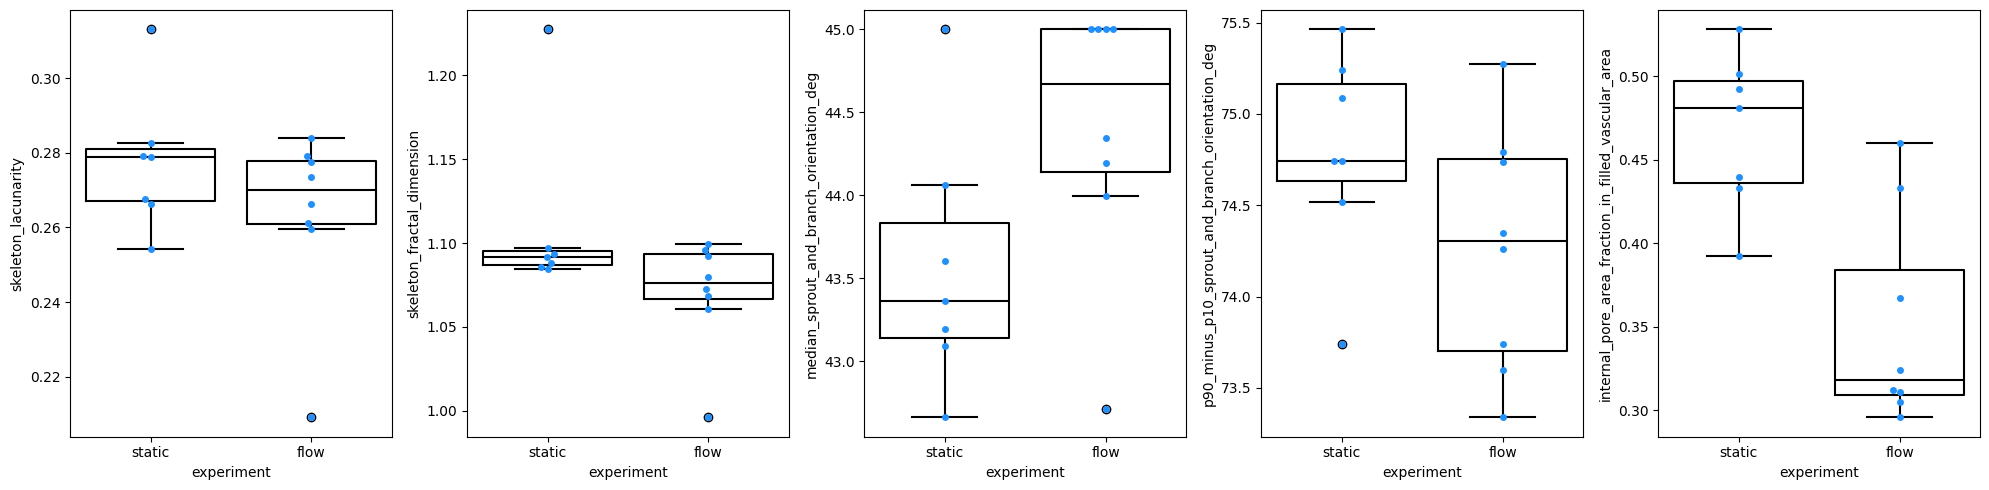

In [9]:
fig, ax = plt.subplots(ncols = 5, figsize=(20,5))
# xorder = ["static", "resevoir", "low_flow", "high_flow"]
xorder = ["static", "flow"]
sns.swarmplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="median_sprout_and_branch_orientation_deg", ax=ax[2], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="median_sprout_and_branch_orientation_deg", ax=ax[2], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="p90_minus_p10_sprout_and_branch_orientation_deg", ax=ax[3], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="p90_minus_p10_sprout_and_branch_orientation_deg", ax=ax[3], fill=False, color="#000000", order=xorder)

sns.swarmplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], zorder=100, color="dodgerblue", order=xorder)
sns.boxplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], fill=False, color="#000000", order=xorder)

plt.tight_layout()

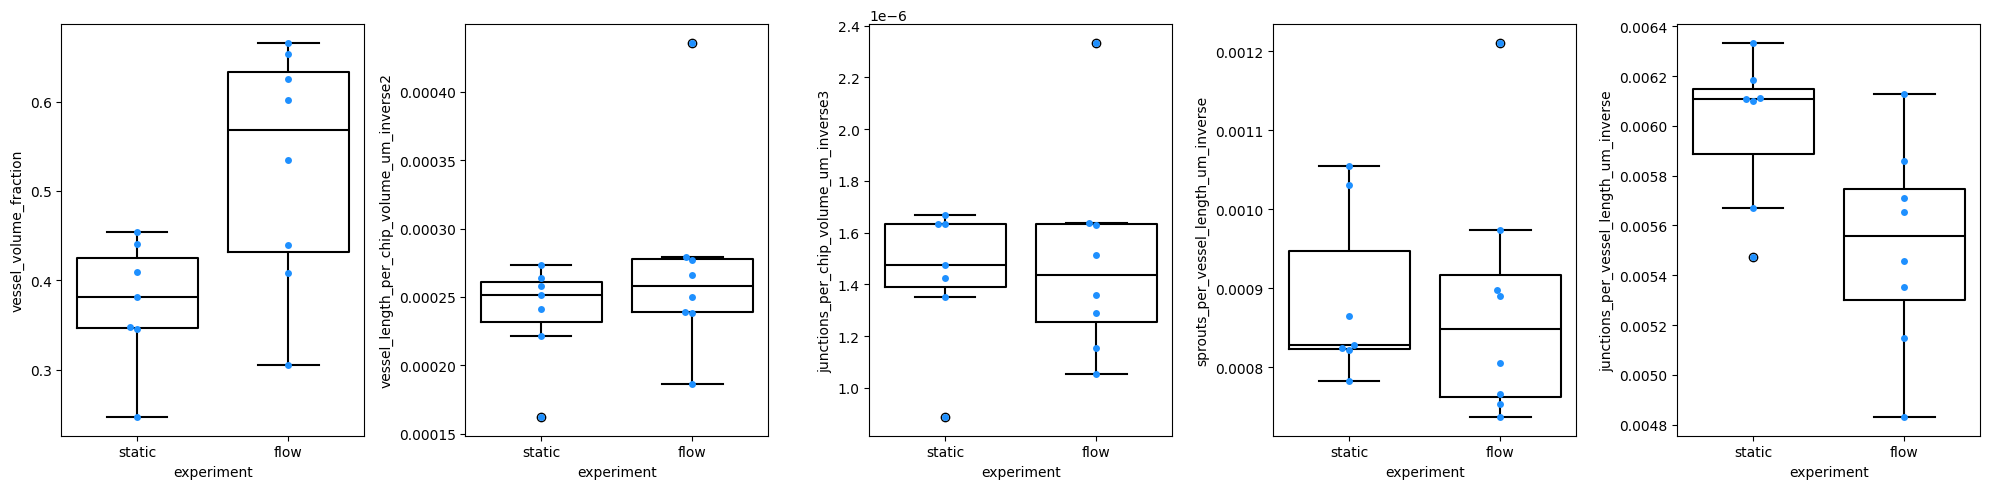

In [10]:
fig, ax = plt.subplots(ncols = 5, figsize=(20,5))
sns.swarmplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], fill=False, color="#000000", order = xorder)

sns.swarmplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], zorder=100, color="dodgerblue", order = xorder)
sns.boxplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], fill=False, color="#000000", order = xorder)

plt.tight_layout()

In [10]:
combined.columns

Index(['image_name', 'source_file', 'image_index', 'chip_volume_um3',
       'vessel_volume_um3', 'vessel_volume_fraction', 'total_vessel_length_um',
       'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_tortuosity',
       'p90_minus_p10_sprout_and_branch_tortuosity',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'total_internal_pore_count',
       'internal_pore_area_fraction_in_filled_vascular_area',
       'median_internal_pore_area_um2', 'p90_minus_p10_internal_pore_area_um2',
       'median_internal_pore_max_inscribed_

In [3]:
root_dir = Path(r"Z:\Bel\Farid\Old_Experiment_Outputs")
# Find all CSV files recursively
csv_files = list(root_dir.rglob("*.csv"))

if not csv_files:
    print("No CSV files found.")
else:
    dfs = []
    
    for f in csv_files:
        if "branch" in str(f):
            try:
                df = pd.read_csv(f)
                df["source_file"] = str(f)          # optional: keep track of original file
                df["source_folder"] = str(f.parent) # optional
                dfs.append(df)
                print(f"Loaded: {f}")
            except Exception as e:
                print(f"Failed to read {f}: {e}")

    if dfs:
        combined = pd.concat(dfs, ignore_index=True, sort=False)
        
        output_file = root_dir / "all_branch_csvs_concatenated.csv"
        combined.to_csv(output_file, index=False)
        
        print(f"\nSaved concatenated CSV to:\n{output_file}")
        print(f"Total files combined: {len(dfs)}")
        print(f"Combined shape: {combined.shape}")
    else:
        print("No CSV files could be read successfully.")

Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\all_branch_csvs_concatenated.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 flow 6million day 7_img1_Valve 2\18.09.25 flow 6million day 7_img1_Valve 2_branch_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 flow 6million day 7_img2_Valve 3\18.09.25 flow 6million day 7_img2_Valve 3_branch_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\18.09.25 flow 6million day 7_img3_Valve 4\18.09.25 flow 6million day 7_img3_Valve 4_branch_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 flow 6million day 7_img0_Valve 1\30.10.25 flow 6million day 7_img0_Valve 1_branch_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 flow 6million day 7_img1_Valve 2\30.10.25 flow 6million day 7_img1_Valve 2_branch_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outputs\30.10.25 flow 6million day 7_img2_Valve 4\30.10.25 flow 6million day 7_img2_Valve 4_branch_metrics.csv
Loaded: Z:\Bel\Farid\Old_Experiment_Outpu

In [4]:
combined["experiment"] = combined.apply(find_condition, axis=1)
combined.columns

Index(['image_name', 'source_file', 'image_index', 'node_start', 'node_end',
       'is_sprout', 'start_z', 'start_y', 'start_x', 'end_z', 'end_y', 'end_x',
       'start_z_um', 'start_y_um', 'start_x_um', 'end_z_um', 'end_y_um',
       'end_x_um', 'path_length_um', 'endpoint_distance_um',
       'mean_cs_area_um2', 'median_cs_area_um2', 'std_cs_area_um2',
       'mean_width_um', 'median_width_um', 'branch_volume_um3',
       'orientation_to_device_axis_deg', 'source_folder', 'experiment'],
      dtype='object')

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_373724\2432278205.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


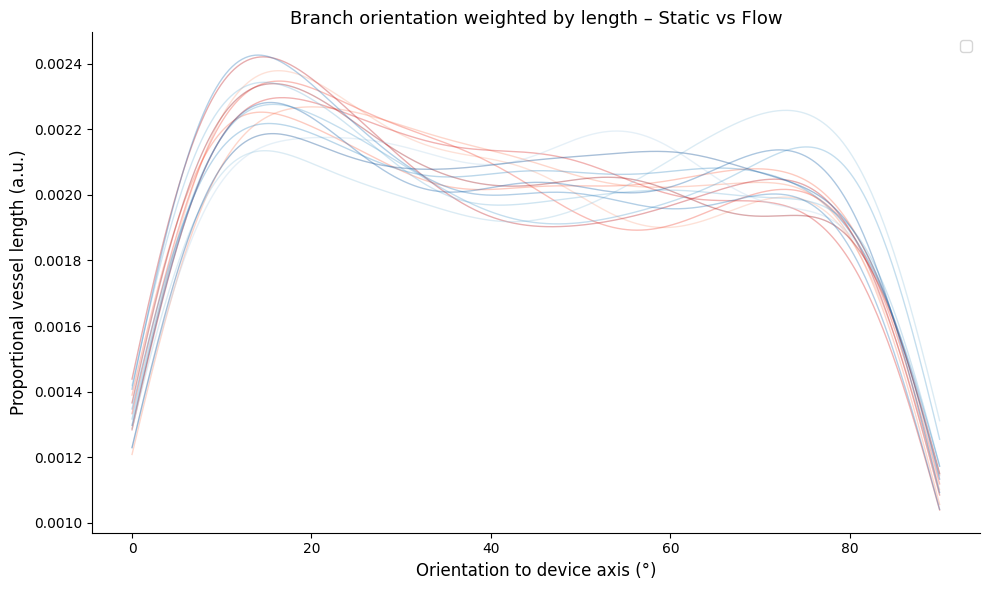

In [8]:
from scipy.stats import gaussian_kde

# Filter to valid data
plot_df = combined.dropna(subset=["orientation_to_device_axis_deg", "path_length_um"]).copy()
plot_df = plot_df[plot_df["experiment"].isin(["static", "flow"])]

# Shared x-axis for evaluation
x_eval = np.linspace(plot_df["orientation_to_device_axis_deg"].min(),
                      plot_df["orientation_to_device_axis_deg"].max(), 500)

# Colour maps: shades of red for static, shades of blue for flow
from matplotlib.cm import Reds, Blues

static_images = sorted(plot_df[plot_df["experiment"] == "static"]["image_name"].unique())
flow_images   = sorted(plot_df[plot_df["experiment"] == "flow"]["image_name"].unique())

static_colors = [Reds(0.3 + 0.6 * i / max(len(static_images) - 1, 1)) for i in range(len(static_images))]
flow_colors   = [Blues(0.3 + 0.6 * i / max(len(flow_images) - 1, 1))   for i in range(len(flow_images))]

fig, ax = plt.subplots(figsize=(10, 6))

# Store KDE values for computing the mean curve
static_kdes = []
flow_kdes   = []

# --- Per-image length-weighted KDE ---
for img_name, color in zip(static_images, static_colors):
    sub = plot_df[plot_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    lengths = sub["path_length_um"].values
    weights = lengths / lengths.sum()          # normalise weights
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval)
    y = y / y.sum()                            # normalise area so curves are comparable
    ax.plot(x_eval, y, color=color, alpha=0.35, linewidth=1)
    static_kdes.append(y)

for img_name, color in zip(flow_images, flow_colors):
    sub = plot_df[plot_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    lengths = sub["path_length_um"].values
    weights = lengths / lengths.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval)
    y = y / y.sum()
    ax.plot(x_eval, y, color=color, alpha=0.35, linewidth=1)
    flow_kdes.append(y)

# --- Mean curves ---
mean_static = np.mean(static_kdes, axis=0)
mean_flow   = np.mean(flow_kdes, axis=0)

# ax.plot(x_eval, mean_static, color="red",  linewidth=2.5, label=f"Mean Static  (n={len(static_images)})")
# ax.plot(x_eval, mean_flow,   color="blue", linewidth=2.5, label=f"Mean Flow  (n={len(flow_images)})")

ax.set_xlabel("Orientation to device axis (°)", fontsize=12)
ax.set_ylabel("Proportional vessel length (a.u.)", fontsize=12)
ax.set_title("Branch orientation weighted by length – Static vs Flow", fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_373724\1579199125.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


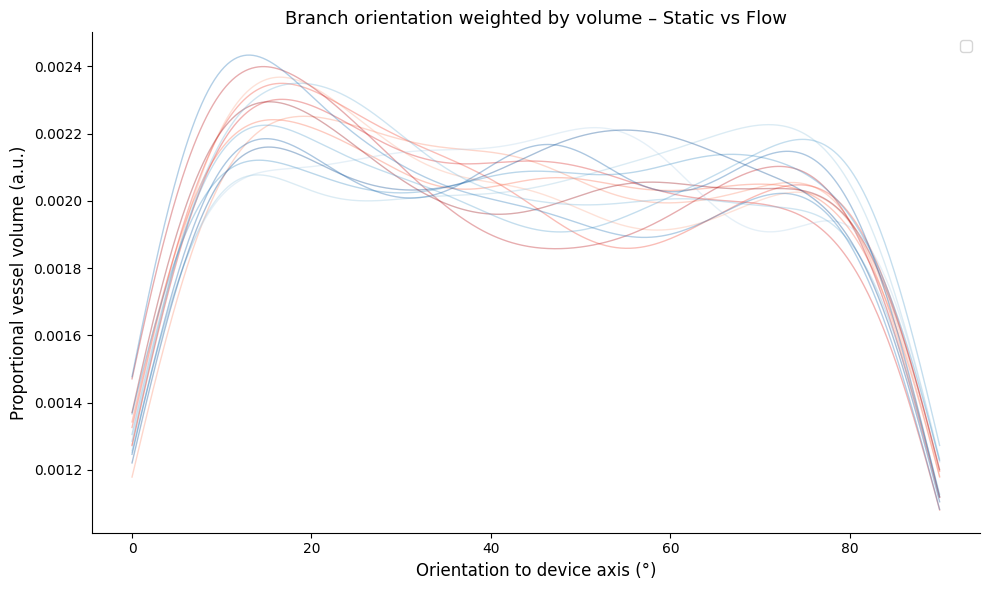

In [7]:
# --- Same plot but weighted by branch VOLUME instead of length ---
vol_df = combined.dropna(subset=["orientation_to_device_axis_deg", "branch_volume_um3"]).copy()
vol_df = vol_df[vol_df["experiment"].isin(["static", "flow"])]

x_eval_v = np.linspace(vol_df["orientation_to_device_axis_deg"].min(),
                        vol_df["orientation_to_device_axis_deg"].max(), 500)

static_images_v = sorted(vol_df[vol_df["experiment"] == "static"]["image_name"].unique())
flow_images_v   = sorted(vol_df[vol_df["experiment"] == "flow"]["image_name"].unique())

static_colors_v = [Reds(0.3 + 0.6 * i / max(len(static_images_v) - 1, 1)) for i in range(len(static_images_v))]
flow_colors_v   = [Blues(0.3 + 0.6 * i / max(len(flow_images_v) - 1, 1))   for i in range(len(flow_images_v))]

fig, ax = plt.subplots(figsize=(10, 6))

static_kdes_v = []
flow_kdes_v   = []

for img_name, color in zip(static_images_v, static_colors_v):
    sub = vol_df[vol_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    volumes = sub["branch_volume_um3"].values
    weights = volumes / volumes.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval_v)
    y = y / y.sum()
    ax.plot(x_eval_v, y, color=color, alpha=0.35, linewidth=1)
    static_kdes_v.append(y)

for img_name, color in zip(flow_images_v, flow_colors_v):
    sub = vol_df[vol_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    volumes = sub["branch_volume_um3"].values
    weights = volumes / volumes.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval_v)
    y = y / y.sum()
    ax.plot(x_eval_v, y, color=color, alpha=0.35, linewidth=1)
    flow_kdes_v.append(y)

mean_static_v = np.mean(static_kdes_v, axis=0)
mean_flow_v   = np.mean(flow_kdes_v, axis=0)

# ax.plot(x_eval_v, mean_static_v, color="red",  linewidth=2.5, label=f"Mean Static  (n={len(static_images_v)})")
# ax.plot(x_eval_v, mean_flow_v,   color="blue", linewidth=2.5, label=f"Mean Flow  (n={len(flow_images_v)})")

ax.set_xlabel("Orientation to device axis (°)", fontsize=12)
ax.set_ylabel("Proportional vessel volume (a.u.)", fontsize=12)
ax.set_title("Branch orientation weighted by volume – Static vs Flow", fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()